# 🧠 Project: MNIST Classification — Implement PCA & GMM from Scratch

---

## 📋 Overview

In this project you will build a complete **handwritten digit classifier** using nothing but `numpy` and `matplotlib`. You will implement:

| Component | What you build |
|---|---|
| **PCA** | Dimensionality reduction via eigen-decomposition |
| **K-Means** | Hard-assignment clustering baseline (motivates GMM) |
| **GMM** | Density estimation via the EM algorithm |
| **Classifier** | Generative classification using log-likelihoods |

Scikit-learn is **only** allowed for loading the dataset and computing evaluation metrics.

---

## 🎯 Learning Objectives

- Derive and implement PCA using the covariance matrix and eigendecomposition
- Implement K-Means and understand it as a special case of EM with **hard** assignments and **isotropic** covariance
- Apply the multivariate Gaussian log-likelihood formula by hand
- Implement the E-step and M-step of the EM algorithm for GMMs
- Understand why generative classifiers compare per-class likelihoods (Bayes' rule / MAP)
- Analyse failure modes through visualisation

---

## 🔤 Notation

| Symbol | Meaning |
|---|---|
| $N$ | number of data points |
| $D$ | original dimensionality (784 for MNIST pixels) |
| $d$ | reduced dimensionality after PCA (`n_components`) |
| $K$ | number of clusters / GMM components |
| $\mathbf{x}_n \in \mathbb{R}^{D \text{ or } d}$ | a single data point (row of $X$) |
| $\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k, \pi_k$ | mean, covariance, and mixing weight of component $k$ |
| $z_i$ | hard cluster assignment of point $i$ (K-Means) |
| $r_{nk}$ | soft responsibility of component $k$ for point $n$ (GMM) |

---

## 📐 Mathematical Background

### Principal Component Analysis (PCA)

Given a mean-centred data matrix $X \in \mathbb{R}^{N \times D}$, the covariance matrix is:

$$\Sigma = \frac{1}{N-1} X^\top X$$

The **principal components** are the eigenvectors of $\Sigma$, sorted by descending eigenvalue. This follows from the fact that the direction of maximum variance of $X$ is the eigenvector of $\Sigma$ with the largest eigenvalue (a Rayleigh-quotient argument — see the reference below if you want the full derivation). Projecting onto the top $d$ eigenvectors reduces dimensionality from $D$ to $d$ while retaining the largest possible share of the variance for that number of dimensions.

$$X_{\text{reduced}} = (X - \bar{\mathbf{x}}) \, V_d, \qquad X_{\text{reconstructed}} \approx X_{\text{reduced}} \, V_d^\top + \bar{\mathbf{x}}$$

where $V_d \in \mathbb{R}^{D \times d}$ holds the top-$d$ eigenvectors as columns.

### K-Means Clustering

K-Means partitions the data into $K$ clusters by alternating a hard **assignment step** and an **update step** (full details and formulas in Part 2):

$$z_i = \arg\min_{k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|_2 \qquad\qquad \boldsymbol{\mu}_k = \frac{1}{|C_k|}\sum_{i: z_i = k} \mathbf{x}_i$$

### Multivariate Gaussian Log-Likelihood

$$\log \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{d}{2}\log(2\pi) - \frac{1}{2}\log|\boldsymbol{\Sigma}| - \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$$

### Gaussian Mixture Model (GMM) — EM Algorithm

A GMM with $K$ components models:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Parameters $\{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}$ are learned by iterating two steps:

**E-step** — compute responsibilities (soft assignments, replacing K-Means' hard $z_i$):
$$r_{nk} = \frac{\pi_k \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j} \pi_j \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

**M-step** — update parameters (a *weighted* version of the K-Means update step):
$$N_k = \sum_n r_{nk}, \quad \boldsymbol{\mu}_k = \frac{1}{N_k}\sum_n r_{nk}\mathbf{x}_n$$
$$\boldsymbol{\Sigma}_k = \frac{1}{N_k}\sum_n r_{nk}(\mathbf{x}_n - \boldsymbol{\mu}_k)(\mathbf{x}_n - \boldsymbol{\mu}_k)^\top, \quad \pi_k = \frac{N_k}{N}$$

### Generative Classification (Bayes' Rule / MAP)

Train one GMM per class $c$. By Bayes' rule, the posterior $p(c \mid \mathbf{x}) \propto p(\mathbf{x} \mid c)\,p(c)$, and since $\log$ is monotonic, the class with the highest posterior is:

$$\hat{y} = \arg\max_{c} \left[ \log p(\mathbf{x} \mid \text{class } c) + \log p(\text{class } c) \right]$$

$p(\mathbf{x} \mid \text{class } c)$ comes from that class's fitted GMM (`score_samples`); $p(\text{class } c)$ is the empirical class frequency in the training set.

---

## 📚 References & Documentation

Everything you need to solve this project is in the sections above and the docstrings in the code cells. The links below are **optional background reading** — useful if a concept feels unfamiliar or you want to see a fuller derivation, but not required to complete the project.

**Concepts**
- [Principal Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) · [Eigendecomposition of a matrix](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix)
- [K-means clustering](https://en.wikipedia.org/wiki/K-means_clustering)
- [Multivariate normal distribution](https://en.wikipedia.org/wiki/Multivariate_normal_distribution)
- [Expectation–maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm) · [Mixture model](https://en.wikipedia.org/wiki/Mixture_model)
- [LogSumExp trick](https://en.wikipedia.org/wiki/LogSumExp) (numerical stability, used throughout the E-step)
- [Bayes' theorem](https://en.wikipedia.org/wiki/Bayes%27_theorem) · [Maximum a posteriori (MAP) estimation](https://en.wikipedia.org/wiki/Maximum_a_posteriori_estimation)

**NumPy functions you'll use**
- [`numpy.linalg.eigh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html) — eigendecomposition for symmetric matrices (PCA)
- [`numpy.linalg.slogdet`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.slogdet.html) — stable $\log|\Sigma|$ (Gaussian log-pdf)
- [`numpy.linalg.solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) — solve $\Sigma^{-1}\mathbf{v}$ without explicit matrix inversion
- [`numpy.linalg.norm`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) — Euclidean distances (K-Means)
- [`numpy.random.default_rng`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.default_rng.html) and [`Generator.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html) — reproducible random initialisation
- [Array broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) — vectorising distance/pdf computations over all points and clusters at once

**Used only for data loading, testing and evaluation (not implementation)**
- [`sklearn.datasets.fetch_openml`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html)
- [`sklearn.metrics.accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [`scipy.stats.multivariate_normal`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html) — reference implementation used only to *test* your Gaussian log-pdf

## ⚙️ Setup — Allowed Imports

In [60]:
# ✅ ONLY these imports are allowed throughout the project
import warnings

import matplotlib.pyplot as plt
import numpy as np

# Sklearn ONLY for dataset loading and evaluation — do not use sklearn models
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

np.random.seed(42)
print("✅ Setup complete.")

✅ Setup complete.


---
## 📦 Part 0 — Load & Prepare the Data

Nothing to implement here. Run this cell to load MNIST and create a stratified subset for faster iteration.

Loading MNIST...
Train: (10000, 784)  |  Test: (2000, 784)
Pixel range: [0.0, 1.0]


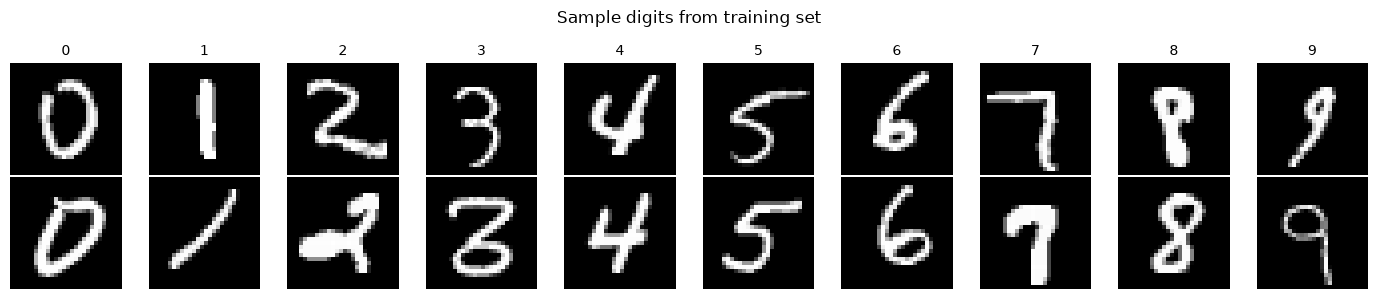

In [61]:
# If fetch_openml raises an SSL certificate error, uncomment:
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context
print("Loading MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_all, y_all = mnist.data / 255.0, mnist.target.astype(int)  # normalize to [0,1]


# Stratified split: 10 000 train / 2 000 test
# (keeps class balance; increase for better accuracy at cost of runtime)
def stratified_split(X, y, n_train_per_class=1000, n_test_per_class=200, seed=42):
    rng = np.random.default_rng(seed)
    tr_idx, te_idx = [], []
    for c in range(10):
        idx = np.where(y == c)[0]
        chosen = rng.choice(idx, n_train_per_class + n_test_per_class, replace=False)
        tr_idx.extend(chosen[:n_train_per_class])
        te_idx.extend(chosen[n_train_per_class:])
    return (X[tr_idx], y[tr_idx], X[te_idx], y[te_idx])


X_train, y_train, X_test, y_test = stratified_split(X_all, y_all)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

# Quick look at the data
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
    for r, idx in enumerate(np.where(y_train == d)[0][:2]):
        axes[r, d].imshow(X_train[idx].reshape(28, 28), cmap="gray")
        axes[r, d].axis("off")
        if r == 0:
            axes[r, d].set_title(str(d), fontsize=10)
plt.suptitle("Sample digits from training set", fontsize=12)
plt.tight_layout()
plt.show()

---
## 🔵 Part 1 — Implement PCA from Scratch

You will write a `PCA` class with `fit`, `transform`, and `inverse_transform` methods.

**No hints for the class structure — read the docstrings and the background section above.**

### What `transform` and `inverse_transform` compute

$$\text{transform}(X) = (X - \bar{\mathbf{x}})\,V_d \qquad\qquad \text{inverse\_transform}(X_{\text{reduced}}) = X_{\text{reduced}} V_d^\top + \bar{\mathbf{x}}$$

where $V_d$ is the $(D \times d)$ matrix of the top-$d$ eigenvectors (`components_`, stored as **rows** — check the docstring for the exact orientation you need).

> 💡 **One hint:** Use `np.linalg.eigh` (not `eig`) to decompose the covariance matrix — it is numerically stable for symmetric matrices and returns real eigenvalues in **ascending** order, so you will need to reverse them.

> 📚 **Why eigenvectors of the covariance matrix?** The direction that maximises the variance of the projected data is exactly the top eigenvector of $\Sigma$ (a constrained-optimisation / Rayleigh-quotient result). See [Principal Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) and [`numpy.linalg.eigh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html) if you want the full derivation — it is not required to complete this part.

<details>
<summary>💡 <b>Pseudocode — PCA.fit</b> (click to expand)</summary>

```text
function fit(X):
    mean          = column-wise mean of X
    X_centred     = X - mean
    covariance    = (X_centred^T @ X_centred) / (N - 1)

    eigenvalues, eigenvectors = eigendecomposition(covariance)   # ascending order!
    order         = indices that sort eigenvalues descending
    eigenvalues   = eigenvalues[order]
    eigenvectors  = eigenvectors[order]

    components               = first n_components eigenvectors (as rows)
    explained_variance       = first n_components eigenvalues
    explained_variance_ratio = explained_variance / sum(ALL eigenvalues)

    store mean, components, explained_variance, explained_variance_ratio
    return self
```

</details>

<details>
<summary>💡 <b>Pseudocode — PCA.transform</b> (click to expand)</summary>

```text
function transform(X):
    X_centred = X - mean
    return X_centred projected onto components   # (N, D) -> (N, n_components)
```

</details>

<details>
<summary>💡 <b>Pseudocode — PCA.inverse_transform</b> (click to expand)</summary>

```text
function inverse_transform(X_reduced):
    return X_reduced projected back to D-dim space, plus mean   # (N, n_components) -> (N, D)
```

</details>

In [62]:
class PCA:
    """
    Principal Component Analysis via eigendecomposition of the covariance matrix.

    Attributes (set during fit)
    ---------------------------
    mean_                     : np.ndarray (D,)     — per-feature mean of training data
    components_               : np.ndarray (n, D)   — top-n eigenvectors (rows), sorted
                                                       by descending eigenvalue
    explained_variance_       : np.ndarray (n,)     — eigenvalues (absolute variance
                                                       captured by each PC)
    explained_variance_ratio_ : np.ndarray (n,)     — fraction of total variance per PC
    """

    def __init__(self, n_components: int):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X: np.ndarray) -> "PCA":
        """
        Compute the mean and top principal components from training data X.

        Steps
        -----
        1. Compute and store the per-feature mean.
        2. Mean-centre X.
        3. Compute the (D x D) covariance matrix.
        4. Eigen-decompose it; sort by descending eigenvalue.
        5. Keep the top `n_components` eigenvectors as rows of `components_`.
        6. Store the top eigenvalues as `explained_variance_`.
        7. Compute and store `explained_variance_ratio_`
           (each eigenvalue divided by the sum of ALL eigenvalues).

        Parameters
        ----------
        X : np.ndarray of shape (N, D)

        Returns
        -------
        self
        """
        # ── YOUR CODE ────────────────────────────────────────────────────────

        #TODO
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        cov_matrix = np.cov(X_centered.T)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        idx = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, idx[:self.n_components]].T
        self.explained_variance_ = eigenvalues[idx[:self.n_components]]
        self.explained_variance_ratio_ = self.explained_variance_ / np.sum(eigenvalues)

        # ─────────────────────────────────────────────────────────────────────
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Project X onto the principal components.

        Parameters
        ----------
        X : np.ndarray of shape (N, D)

        Returns
        -------
        np.ndarray of shape (N, n_components)
        """
        # ── YOUR CODE ────────────────────────────────────────────────────────

        #TODO 
        X_centered = X - self.mean_
        return X_centered @ self.components_.T

        # ─────────────────────────────────────────────────────────────────────

    def inverse_transform(self, X_reduced: np.ndarray) -> np.ndarray:
        """
        Reconstruct approximate original-space vectors from projections.

        Parameters
        ----------
        X_reduced : np.ndarray of shape (N, n_components)

        Returns
        -------
        np.ndarray of shape (N, D)
        """
        # ── YOUR CODE ────────────────────────────────────────────────────────

        #TODO
        return X_reduced @ self.components_ + self.mean_

        # ─────────────────────────────────────────────────────────────────────


print("PCA class defined — implement the methods above, then run the tests below.")

PCA class defined — implement the methods above, then run the tests below.


Variance explained by 50 PCs: 82.5%
✅ PCA tests passed!


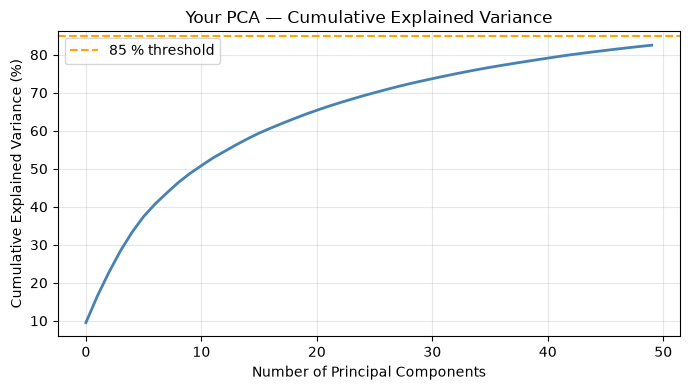

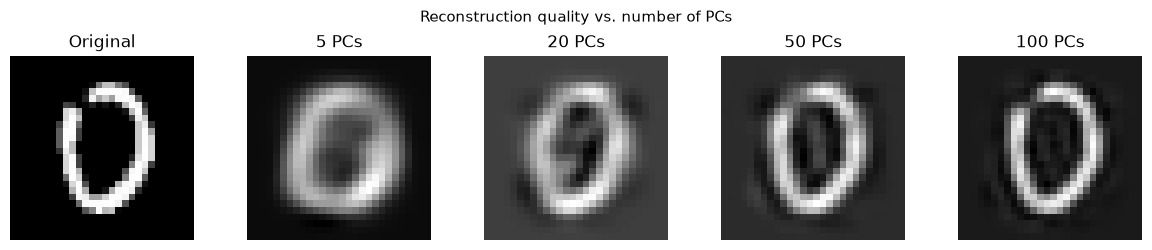

In [63]:
# ── PCA Tests ─────────────────────────────────────────────────────────────
pca = PCA(n_components=50)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

assert X_train_pca.shape == (len(X_train), 50), "❌ transform output shape wrong"
assert X_test_pca.shape == (len(X_test), 50), "❌ test transform shape wrong"

recon = pca.inverse_transform(X_train_pca)
assert recon.shape == X_train.shape, "❌ inverse_transform shape wrong"

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"Variance explained by 50 PCs: {var_explained:.1f}%")
assert var_explained > 60, "❌ Expected > 60% variance with 50 components"

print("✅ PCA tests passed!")

# Plot: cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, color="steelblue", lw=2)
plt.axhline(85, color="orange", ls="--", label="85 % threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Your PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot: reconstruction quality at various n_components
ns = [5, 20, 50, 100]
sample_img = X_train[0]
fig, axes = plt.subplots(1, len(ns) + 1, figsize=(12, 2.5))
axes[0].imshow(sample_img.reshape(28, 28), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
for ax, n in zip(axes[1:], ns):
    p = PCA(n_components=n).fit(X_train)
    recon_n = p.inverse_transform(p.transform(sample_img[None]))[0]
    ax.imshow(recon_n.reshape(28, 28), cmap="gray")
    ax.set_title(f"{n} PCs")
    ax.axis("off")
plt.suptitle("Reconstruction quality vs. number of PCs", fontsize=11)
plt.tight_layout()
plt.show()

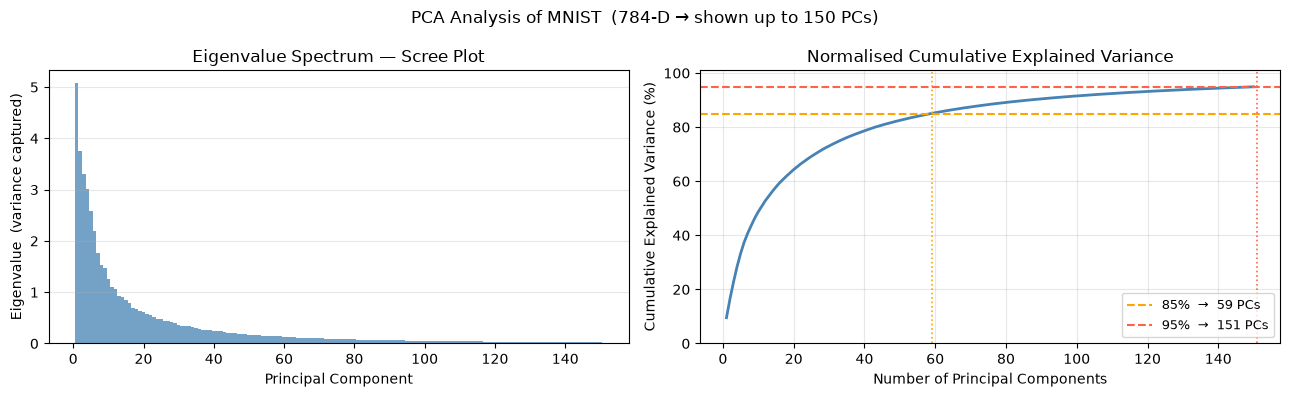

Components needed for 85% variance: 59
Components needed for 95% variance: 151
(We use 50 components → 82.5% variance)


In [64]:
# ── PCA Visualisation ────────────────────────────────────────────────────────
# Fit with more components to reveal the full eigenvalue spectrum
pca_vis = PCA(n_components=150).fit(X_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — eigenvalue spectrum (scree plot)
axes[0].bar(
    range(1, 151), pca_vis.explained_variance_, color="steelblue", alpha=0.75, width=1.0
)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Eigenvalue  (variance captured)")
axes[0].set_title("Eigenvalue Spectrum — Scree Plot")
axes[0].grid(axis="y", alpha=0.3)

# Right — normalised cumulative explained variance
cumvar = np.cumsum(pca_vis.explained_variance_ratio_) * 100
axes[1].plot(range(1, 151), cumvar, color="steelblue", lw=2)

for thresh, col in [(85, "orange"), (95, "tomato")]:
    n_needed = int(np.searchsorted(cumvar, thresh)) + 1
    axes[1].axhline(
        thresh, color=col, ls="--", lw=1.5, label=f"{thresh}%  →  {n_needed} PCs"
    )
    axes[1].axvline(n_needed, color=col, ls=":", lw=1.2)

axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Normalised Cumulative Explained Variance")
axes[1].set_ylim(0, 101)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("PCA Analysis of MNIST  (784-D → shown up to 150 PCs)", fontsize=12)
plt.tight_layout()
plt.show()

n85 = int(np.searchsorted(cumvar, 85)) + 1
n95 = int(np.searchsorted(cumvar, 95)) + 1
print(f"Components needed for 85% variance: {n85}")
print(f"Components needed for 95% variance: {n95}")
print(
    f"(We use {pca.n_components} components → {pca.explained_variance_ratio_.sum()*100:.1f}% variance)"
)

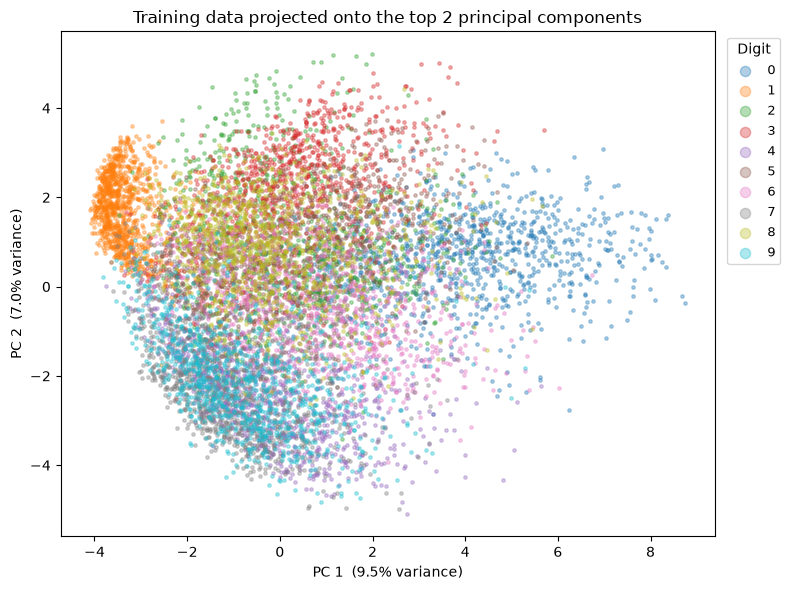

Observation: even 2 PCs separate some digit clusters (e.g. 0 vs 1),
but most digits heavily overlap — that is why we use more PCs for classification.


In [65]:
# ── 2-D PCA projection — structure of the data ──────────────────────────────
pca2 = PCA(n_components=2).fit(X_train)
X_train_2d = pca2.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(range(10))
for digit in range(10):
    mask = y_train == digit
    ax.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        s=6,
        alpha=0.35,
        color=colors[digit],
        label=str(digit),
    )

ax.set_xlabel(f"PC 1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC 2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Training data projected onto the top 2 principal components")
ax.legend(
    title="Digit", markerscale=3, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9
)
plt.tight_layout()
plt.show()

print("Observation: even 2 PCs separate some digit clusters (e.g. 0 vs 1),")
print(
    "but most digits heavily overlap — that is why we use more PCs for classification."
)

---
## 🔵 Part 2 — K-Means Classifier

### Algorithm

K-Means partitions $n$ points into $k$ clusters by alternating two steps until
the centroids stop moving:

**Assignment step** — assign each point to its nearest centroid:
$$z_i = \arg\min_{j \in \{1,\ldots,k\}} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|_2$$

**Update step** — recompute each centroid as the mean of its assigned points:
$$\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{i:\, z_i = j} \mathbf{x}_i$$

> **Connection to GMM:** K-Means is a special case of the EM algorithm with
> **hard** (0/1) responsibilities and **isotropic** covariance
> $\boldsymbol{\Sigma}_k = \sigma^2\mathbf{I}$. Implementing it now makes the
> jump to GMM in Part 4 much clearer.

### Classifier

Train $k$ centroids per digit class, then classify a test point by finding the
**nearest centroid across all classes**.

We run two settings and compare both with the GMM in Part 6:

| Model | Centroids / class | Covariance | Assignments |
|---|---|---|---|
| K-Means K=1 | 1 (the class mean) | isotropic | hard |
| K-Means K=4 | 4 | isotropic | hard |
| GMM K=4 | 4 Gaussians | **full** | **soft** |

> 💡 **Implementation hints:**
> - `assign_clusters`: compute all pairwise distances at once with [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) (`X[:, None, :] - centroids[None, :, :]`), then reduce with [`np.linalg.norm`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)`(..., axis=2)` and `argmin`.
> - `kmeans`: pick initial centroids with a random, non-repeating subset of data points (see [`Generator.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)) and iterate assign → update until the centroids barely move.
> - Background: [K-means clustering](https://en.wikipedia.org/wiki/K-means_clustering) (this project implements Lloyd's algorithm, the "standard algorithm" section on that page).

<details>
<summary>💡 <b>Pseudocode — assign_clusters</b> (click to expand)</summary>

```text
function assign_clusters(X, centroids):
    # vectorised — no explicit Python loop over points needed
    distances = for every point, the distance to every centroid   # shape (N, K)
    return, for each point, the index of its closest centroid     # shape (N,)
```

</details>

In [66]:
def assign_clusters(X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """
    Assign each point to its nearest centroid (hard assignment).

    Parameters
    ----------
    X         : np.ndarray (N, d)
    centroids : np.ndarray (K, d)

    Returns
    -------
    labels : np.ndarray (N,)  — integer cluster index in {0, ..., K-1}
    """
    # ── YOUR CODE ────────────────────────────────────────────────────────────
    # TODO:
    #  Compute the Euclidean distance from every point to every centroid.
    #       Distance matrix shape: (N, K).
    #
    #   Hint: broadcast X[:, np.newaxis, :] vs centroids[np.newaxis, :, :]
    #         → differences of shape (N, K, d) → norm over axis=2.
    #
    #       Then return the index of the nearest centroid per point (argmin).
    broadcasted_diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    distance_matrix = np.linalg.norm(broadcasted_diff, axis=2)
    return np.argmin(distance_matrix, axis=1)

    # ─────────────────────────────────────────────────────────────────────────

<details>
<summary>💡 <b>Pseudocode — update_centroids</b> (click to expand)</summary>

```text
function update_centroids(X, labels, k):
    centroids = zeros(k, d)
    for j in 0 .. k-1:
        points_in_cluster_j = all rows of X where labels == j
        if points_in_cluster_j is not empty:
            centroids[j] = mean of points_in_cluster_j
        # (an empty cluster can be left at zero — rare with a good init)
    return centroids
```

</details>

In [67]:
def update_centroids(X: np.ndarray, labels: np.ndarray, k: int) -> np.ndarray:
    """
    Recompute each centroid as the mean of its assigned points.

    Parameters
    ----------
    X      : np.ndarray (N, d)
    labels : np.ndarray (N,)   — cluster assignments from assign_clusters
    k      : int               — number of clusters

    Returns
    -------
    centroids : np.ndarray (K, d)
    """
    d = X.shape[1]
    centroids = np.zeros((k, d))
    # ── YOUR CODE ────────────────────────────────────────────────────────────
    # TODO: 
    # For each cluster j in {0, ..., k-1}:
    #         select the rows of X where labels == j,
    #         set centroids[j] to their mean along axis=0.
    for j in range(k):
        centroids[j] = X[labels == j].mean(axis=0)
    
    return centroids
    # ─────────────────────────────────────────────────────────────────────────

<details>
<summary>💡 <b>Pseudocode — kmeans</b> (click to expand)</summary>

```text
function kmeans(X, k, max_iter, tol):
    centroids = k distinct, randomly chosen rows of X          # given

    repeat up to max_iter times:
        labels        = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if largest centroid movement < tol:
            stop early
        centroids = new_centroids

    labels = assign_clusters(X, centroids)   # final assignment after last update
    return centroids, labels
```

</details>

In [68]:
def kmeans(
    X: np.ndarray,
    k: int,
    max_iter: int = 100,
    tol: float = 1e-4,
    random_state: int = 42,
) -> tuple:
    """
    Run the K-Means algorithm until convergence or max_iter steps.

    Parameters
    ----------
    X            : np.ndarray (N, d)
    k            : int   — number of clusters
    max_iter     : int   — maximum iterations
    tol          : float — stop when the largest centroid shift < tol
    random_state : int

    Returns
    -------
    centroids : np.ndarray (K, d)
    labels    : np.ndarray (N,)
    """
    # Initialisation — provided
    rng = np.random.default_rng(random_state)
    centroids = X[rng.choice(len(X), size=k, replace=False)].copy()

    # ── YOUR CODE ────────────────────────────────────────────────────────────
    # TODO: Iterate up to max_iter times:
    #   1. labels        = assign_clusters(X, centroids)
    #   2. new_centroids = update_centroids(X, labels, k)
    #   3. if np.max(np.abs(new_centroids - centroids)) < tol: break
    #   4. centroids = new_centroids
    # After the loop, compute the final labels and return (centroids, labels).
    for _ in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.max(np.abs(new_centroids - centroids)) < tol:
            break
        centroids = new_centroids

    labels = assign_clusters(X, centroids)
    return centroids, labels

    # ─────────────────────────────────────────────────────────────────────────

✅ kmeans test passed


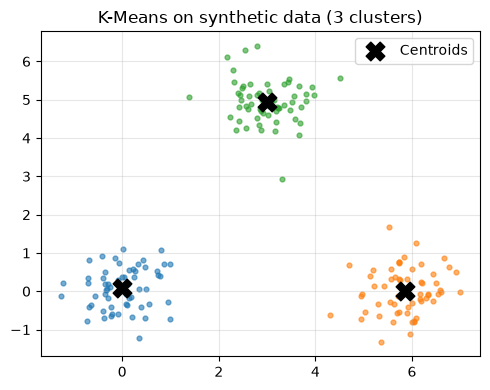

In [69]:
# ── Quick test on synthetic data ─────────────────────────────────────────────
rng_t = np.random.default_rng(0)
X_t = np.vstack(
    [
        rng_t.multivariate_normal(m, np.eye(2) * 0.3, 60)
        for m in [[0, 0], [6, 0], [3, 5]]
    ]
)

c_t, l_t = kmeans(X_t, k=3, random_state=7)

assert c_t.shape == (3, 2), "\u274c centroids shape should be (k, d)"
assert l_t.shape == (len(X_t),), "\u274c labels shape should be (N,)"
assert len(np.unique(l_t)) == 3, "\u274c expected 3 distinct clusters"
print("\u2705 kmeans test passed")

fig, ax = plt.subplots(figsize=(5, 4))
for j in range(3):
    pts = X_t[l_t == j]
    ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.6)
ax.scatter(
    c_t[:, 0], c_t[:, 1], marker="X", s=180, c="black", zorder=5, label="Centroids"
)
ax.set_title("K-Means on synthetic data (3 clusters)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<details>
<summary>💡 <b>Pseudocode — train_kmeans_classifier</b> (click to expand)</summary>

```text
function train_kmeans_classifier(X_pca, y, k_per_class):
    class_centroids = {}
    for each distinct class c in y:
        X_c              = rows of X_pca belonging to class c
        centroids_c, _   = kmeans(X_c, k_per_class)
        class_centroids[c] = centroids_c
    return class_centroids
```

</details>

<details>
<summary>💡 <b>Pseudocode — predict_kmeans</b> (click to expand)</summary>

```text
function predict_kmeans(X_pca, class_centroids):
    for each class c:
        distances_c   = distance from every test point to every centroid of class c
        best_c        = the SMALLEST distance per point   # "how well c explains this point"
    predict, for each point, the class whose best_c is smallest overall
```

</details>

In [70]:
def train_kmeans_classifier(
    X_pca: np.ndarray, y: np.ndarray, k_per_class: int = 4
) -> dict:
    """
    Run K-Means independently on each digit class.

    Returns
    -------
    class_centroids : dict {class_label -> np.ndarray (k_per_class, d)}
    """
    class_centroids = {}
    for c in np.unique(y):
        # ── YOUR CODE ────────────────────────────────────────────────────────
        # TODO: call kmeans(X_pca[y == c], k_per_class, random_state=42+c)
        #       and store the returned centroids in class_centroids[c]
        class_centroids[c], _ = kmeans(X_pca[y == c], k_per_class, random_state=42+c)
        
        
        # ─────────────────────────────────────────────────────────────────────
    return class_centroids


def predict_kmeans(X_pca: np.ndarray, class_centroids: dict) -> np.ndarray:
    """
    Classify each sample by the nearest centroid across all classes.

    Returns
    -------
    y_pred : np.ndarray (N,)
    """
    classes = sorted(class_centroids.keys())
    # ── YOUR CODE ────────────────────────────────────────────────────────────
    # TODO: For each class c, compute the distance from every test point
    #       to every centroid of class c, then take the minimum.
    #       Classify each point to the class with the smallest min-distance.
    distances = np.zeros((X_pca.shape[0], len(classes)))
    for i, c in enumerate(classes):
        centroids = class_centroids[c]
        distances[:, i] = np.min(np.linalg.norm(X_pca[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2), axis=1)
    return np.argmin(distances, axis=1)

    # ─────────────────────────────────────────────────────────────────────────

In [71]:
# ── Run K-Means classifier on MNIST ─────────────────────────────────────────
_pca_km = PCA(n_components=50).fit(X_train)
X_tr_km = _pca_km.transform(X_train)
X_te_km = _pca_km.transform(X_test)

# K=1 per class — nearest centroid (equivalent to the class mean)
cc_k1 = train_kmeans_classifier(X_tr_km, y_train, k_per_class=1)
acc_baseline = accuracy_score(y_test, predict_kmeans(X_te_km, cc_k1)) * 100

# K=4 per class — same number of prototypes as the GMM we will build
cc_k4 = train_kmeans_classifier(X_tr_km, y_train, k_per_class=4)
acc_kmeans = accuracy_score(y_test, predict_kmeans(X_te_km, cc_k4)) * 100

print(f"K-Means  K=1  (nearest centroid) : {acc_baseline:.1f}%")
print(f"K-Means  K=4                     : {acc_kmeans:.1f}%")
print(f"(GMM K=4 result will appear in Part 6 \u2192 beat both!)")

K-Means  K=1  (nearest centroid) : 78.8%
K-Means  K=4                     : 87.7%
(GMM K=4 result will appear in Part 6 → beat both!)


---
## 🔵 Part 3 — From Hard Assignments to Soft: The Multivariate Gaussian

K-Means assigns each point to **exactly one** centroid — a hard cut.
Look back at the 2-D PCA scatter from Part 1: digits like *4* and *9* heavily overlap.
A hard boundary will always misclassify the ambiguous points in between.

What if we instead asked: *what is the **probability** that $\mathbf{x}$ belongs
to cluster $k$?*  The natural answer is to model each cluster as a
**multivariate Gaussian** $\mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$
and assign soft membership weights via Bayes' rule.
Part 4 builds that full model. First, you need a numerically stable Gaussian log-PDF:

$$\log \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{d}{2}\log(2\pi) - \frac{1}{2}\log|\boldsymbol{\Sigma}| - \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$$

We work in **log-space** rather than computing $\mathcal{N}(\cdot)$ directly, because in $d\approx 50$ dimensions the raw density can be astronomically small (or its normalising constant astronomically large) and overflow/underflow in `float64` — the log keeps every intermediate quantity in a numerically safe range.

> 💡 **One hint:** Use `np.linalg.slogdet` to compute $\log|\Sigma|$ without overflow,
> and `np.linalg.solve(Sigma, (X - mu).T).T` instead of explicitly inverting $\Sigma$ — solving a linear system is both faster and more numerically stable than computing $\Sigma^{-1}$ directly.

> 📚 **References:** [`numpy.linalg.slogdet`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.slogdet.html), [`numpy.linalg.solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html), [Multivariate normal distribution](https://en.wikipedia.org/wiki/Multivariate_normal_distribution).

<details>
<summary>💡 <b>Pseudocode — multivariate_gaussian_log_pdf</b> (click to expand)</summary>

```text
function log_pdf(X, mu, Sigma):
    d          = number of dimensions
    X_centred  = X - mu
    log_det    = log|Sigma|                       # via slogdet, NOT log(det(Sigma))
    v          = solve Sigma @ v = X_centred^T     # avoids explicit Sigma^-1
    mahalanobis[n] = X_centred[n] · v[:, n]        # per-point quadratic form

    return -0.5 * ( d*log(2*pi) + log_det + mahalanobis )   # shape (N,)
```

</details>

In [72]:
def multivariate_gaussian_log_pdf(
    X: np.ndarray, mu: np.ndarray, Sigma: np.ndarray
) -> np.ndarray:
    """
    Compute the log-probability density of each row of X under
    N(mu, Sigma).

    Parameters
    ----------
    X     : np.ndarray of shape (N, d) — data points
    mu    : np.ndarray of shape (d,)   — mean vector
    Sigma : np.ndarray of shape (d, d) — covariance matrix

    Returns
    -------
    log_probs : np.ndarray of shape (N,)
                log N(x_n | mu, Sigma) for each n
    """
    d = X.shape[1]

    # ── YOUR CODE ────────────────────────────────────────────────────────────

    # TODO
    X_centered = X - mu
    log_det_Sigma = np.linalg.slogdet(Sigma)[1]
    inv_Sigma = np.linalg.inv(Sigma)
    log_probs = -0.5 * (d * np.log(2 * np.pi) + log_det_Sigma + np.sum(X_centered @ inv_Sigma * X_centered, axis=1))

    return log_probs



    # ─────────────────────────────────────────────────────────────────────────


# Quick sanity check
rng = np.random.default_rng(0)
d = 4
mu_test = rng.standard_normal(d)
A = rng.standard_normal((d, d))
Sigma_test = A @ A.T + np.eye(d) * 0.5  # guaranteed positive-definite
X_test_g = rng.multivariate_normal(mu_test, Sigma_test, size=200)

log_probs = multivariate_gaussian_log_pdf(X_test_g, mu_test, Sigma_test)
assert log_probs.shape == (200,), "❌ Output shape should be (N,)"
assert np.all(log_probs < 0), "❌ Log-probabilities should be negative"

# Compare average log-likelihood to scipy reference
from scipy.stats import multivariate_normal as sp_mvn

ref = sp_mvn.logpdf(X_test_g, mean=mu_test, cov=Sigma_test)
assert np.allclose(log_probs, ref, atol=1e-6), "❌ Values don't match scipy reference"
print(
    f"✅ log-pdf matches scipy reference (max diff = {np.abs(log_probs - ref).max():.2e})"
)

✅ log-pdf matches scipy reference (max diff = 1.24e-14)


---
## 🔵 Part 4 — Implement the GMM EM Algorithm

Now implement a full `GMM` class. The structure mirrors sklearn's `GaussianMixture` but **every line** of maths is yours.

**Read the docstrings and the EM equations in the background section carefully.**

### The log-sum-exp trick, worked example

In the E-step you need $\log \sum_k \pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$, but you only have the **log** of each term, $\ell_k = \log(\pi_k \mathcal{N}_k)$. Exponentiating each $\ell_k$ before summing can underflow to exactly `0.0` (e.g. `np.exp(-800)` in a 50-D Gaussian is common). The fix: factor out the largest term.

$$\log\sum_k e^{\ell_k} = m + \log\sum_k e^{\ell_k - m}, \qquad m = \max_k \ell_k$$

Concretely, with $\ell = [-1000,\ -1002,\ -1005]$: computing `np.exp(ℓ)` directly gives `[0., 0., 0.]` (all underflow) and `log(0)` is `-inf`. Subtracting $m=-1000$ first gives `[0, -2, -5]`, whose exponentials `[1, 0.135, 0.0067]` are safe to sum, and adding $m$ back at the end recovers the correct (finite) answer.

$$\text{log\_sum} = m + \log\Big(\textstyle\sum_k e^{\ell_k - m}\Big) \qquad\qquad r_{nk} = \exp(\ell_k - \text{log\_sum})$$

> 💡 **One hint:** In the E-step, compute log-responsibilities first (`log_r[:, k] = log π_k + log N(x_n|μ_k,Σ_k)`), take the row-wise max, then apply the formula above per row to get both the normalised responsibilities `r` and the total log-likelihood (sum of `log_sum` over all points).

> 📚 **References:** [Expectation–maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), [LogSumExp trick](https://en.wikipedia.org/wiki/LogSumExp). (You must implement log-sum-exp yourself with plain numpy — do not import `scipy.special.logsumexp`.)

<details>
<summary>💡 <b>Pseudocode — GMM._init_params</b> (click to expand)</summary>

```text
function _init_params(X):
    means      = K distinct, randomly chosen rows of X
    weights    = 1/K for every component (uniform)
    covariance = sample covariance of ALL of X, + reg_covar * I
    every component starts with the SAME covariance matrix (only means differ)
```

</details>

<details>
<summary>💡 <b>Pseudocode — GMM._e_step</b> (click to expand)</summary>

```text
function _e_step(X):
    for each component k:
        log_r[:, k] = log(weights[k]) + log_pdf(X, means[k], covariances[k])

    m               = row-wise max of log_r                       # log-sum-exp trick
    log_likelihood  = sum over points of ( m + log sum_k exp(log_r - m) )

    r = exp(log_r - m)
    normalise each row of r to sum to 1                            # responsibilities
    return r, log_likelihood
```

</details>

<details>
<summary>💡 <b>Pseudocode — GMM._m_step</b> (click to expand)</summary>

```text
function _m_step(X, r):
    N_k     = column sums of r                          # "effective" points per component
    weights = N_k / N

    for each component k:
        means[k] = weighted average of X, weighted by r[:, k]

    for each component k:
        diff           = X - means[k]
        covariances[k] = (r[:,k]-weighted diff)^T @ diff / N_k[k]
        covariances[k] += reg_covar * I
```

</details>

<details>
<summary>💡 <b>Pseudocode — GMM.fit</b> (click to expand)</summary>

```text
function fit(X):
    _init_params(X)
    previous_log_likelihood = -infinity

    repeat up to max_iter times:
        r, log_likelihood = _e_step(X)
        _m_step(X, r)
        store log_likelihood
        if |log_likelihood - previous_log_likelihood| < tol:
            stop early
        previous_log_likelihood = log_likelihood

    return self
```

</details>

<details>
<summary>💡 <b>Pseudocode — GMM.score_samples</b> (click to expand)</summary>

```text
function score_samples(X):
    for each component k:
        log_p[:, k] = log(weights[k]) + log_pdf(X, means[k], covariances[k])
    return log-sum-exp of log_p across components, per row   # shape (N,)
```

</details>

In [73]:
class GMM:
    """
    Gaussian Mixture Model fitted with the EM algorithm.

    Parameters
    ----------
    n_components : int   — number of mixture components K
    max_iter     : int   — maximum EM iterations
    tol          : float — stop when log-likelihood improvement < tol
    reg_covar    : float — small value added to diagonal of each Σ_k
                          for numerical stability
    random_state : int

    Attributes (set during fit)
    ---------------------------
    weights_     : np.ndarray (K,)       — π_k
    means_       : np.ndarray (K, d)     — μ_k
    covariances_ : np.ndarray (K, d, d)  — Σ_k
    log_likelihoods_ : list[float]       — per-iteration total log-likelihood
    """

    def __init__(
        self, n_components=3, max_iter=100, tol=1e-4, reg_covar=1e-4, random_state=42
    ):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.random_state = random_state

        self.weights_ = None
        self.means_ = None
        self.covariances_ = None
        self.log_likelihoods_ = []

    # ------------------------------------------------------------------
    # Private helpers — implement these first
    # ------------------------------------------------------------------

    def _init_params(self, X: np.ndarray):
        """
        Initialise π, μ, Σ before the EM loop.

        Strategy: choose K data points at random as initial means,
        set all weights equal (1/K), and initialise each covariance
        to the sample covariance of X — not the identity matrix,
        which is a poor initialisation when feature variances differ.
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        rng = np.random.default_rng(self.random_state)
        means = X[rng.choice(X.shape[0], self.n_components, replace=False)]
        weights = np.ones(self.n_components) / self.n_components
        covariances = np.array([np.cov(X, rowvar=False) + self.reg_covar * np.eye(X.shape[1]) for _ in range(self.n_components)])
        self.means_ = means.astype(np.float64)
        self.weights_ = weights
        self.covariances_ = covariances

        # ───────────────────────────────────────────────────────────────────

    def _e_step(self, X: np.ndarray) -> tuple[np.ndarray, float]:
        """
        Compute responsibilities r_nk and total log-likelihood.

        Returns
        -------
        r        : np.ndarray (N, K)  — normalised responsibilities
        log_like : float              — total log-likelihood log p(X)
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        for k in range(self.n_components):
            log_prob_k = multivariate_gaussian_log_pdf(X, self.means_[k], self.covariances_[k])
            log_prob_k += np.log(self.weights_[k])
            if k == 0:
                log_probs = log_prob_k[:, np.newaxis]
            else:
                log_probs = np.hstack((log_probs, log_prob_k[:, np.newaxis]))
        log_sum_exp = np.logaddexp.reduce(log_probs, axis=1)
        r = np.exp(log_probs - log_sum_exp[:, np.newaxis])
        log_like = np.sum(log_sum_exp)  

        return r, log_like

        # ───────────────────────────────────────────────────────────────────

    def _m_step(self, X: np.ndarray, r: np.ndarray):
        """
        Update π_k, μ_k, Σ_k given responsibilities r.

        Remember to add `reg_covar * I` to each covariance for stability.
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        for k in range(self.n_components):
            r_k = r[:, k:k+1]
            self.weights_[k] = np.sum(r_k)
            self.means_[k] = np.sum(r_k * X, axis=0) / self.weights_[k]
            diff = X - self.means_[k]
            self.covariances_[k] = np.dot(diff.T, diff * r_k) / self.weights_[k] + self.reg_covar * np.eye(X.shape[1])

        # ───────────────────────────────────────────────────────────────────

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def fit(self, X: np.ndarray) -> "GMM":
        """
        Run the EM algorithm until convergence or max_iter.

        Steps
        -----
        1. Initialise parameters.
        2. Repeat until |ΔLL| < tol or max_iter reached:
            a. E-step → responsibilities & log-likelihood
            b. M-step → update parameters
            c. Store log-likelihood; check convergence.

        Parameters
        ----------
        X : np.ndarray of shape (N, d)

        Returns
        -------
        self
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        self._init_params(X)
        prev_log_like = None
        for _ in range(self.max_iter):
            r, log_like = self._e_step(X)
            self._m_step(X, r)
            self.log_likelihoods_.append(log_like)
            if prev_log_like is not None and abs(log_like - prev_log_like) < self.tol:
                break
            prev_log_like = log_like

        # ───────────────────────────────────────────────────────────────────
        return self

    def score_samples(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the per-sample log-likelihood log p(x_n) under the fitted GMM.

        log p(x) = log Σ_k π_k N(x | μ_k, Σ_k)

        Parameters
        ----------
        X : np.ndarray of shape (N, d)

        Returns
        -------
        np.ndarray of shape (N,)
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        log_probs = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            log_probs[:, k] = multivariate_gaussian_log_pdf(X, self.means_[k], self.covariances_[k]) + np.log(self.weights_[k])
        log_like = np.logaddexp.reduce(log_probs, axis=1)

        return log_like

        # ───────────────────────────────────────────────────────────────────

    def sample(self, n: int) -> np.ndarray:
        """
        Draw n new samples from the fitted mixture.

        For each of the n samples:
          1. pick a component k ~ Categorical(weights_)
          2. draw x ~ N(mu_k, Sigma_k)

        Parameters
        ----------
        n : int  — number of samples to generate

        Returns
        -------
        np.ndarray of shape (n, d)
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────
        rng = np.random.default_rng(self.random_state)
        ks = rng.choice(
            self.n_components, size=n, p=self.weights_ / self.weights_.sum()
        )
        samples = np.array(
            [rng.multivariate_normal(self.means_[k], self.covariances_[k]) for k in ks]
        )
        return samples
        # ───────────────────────────────────────────────────────────────────


print("GMM class defined — implement the methods above, then run the tests below.")

GMM class defined — implement the methods above, then run the tests below.


Log-likelihood range: -3042.1 → 1961.4 (6 iterations)
Max mean error: 0.158
✅ All GMM tests passed!


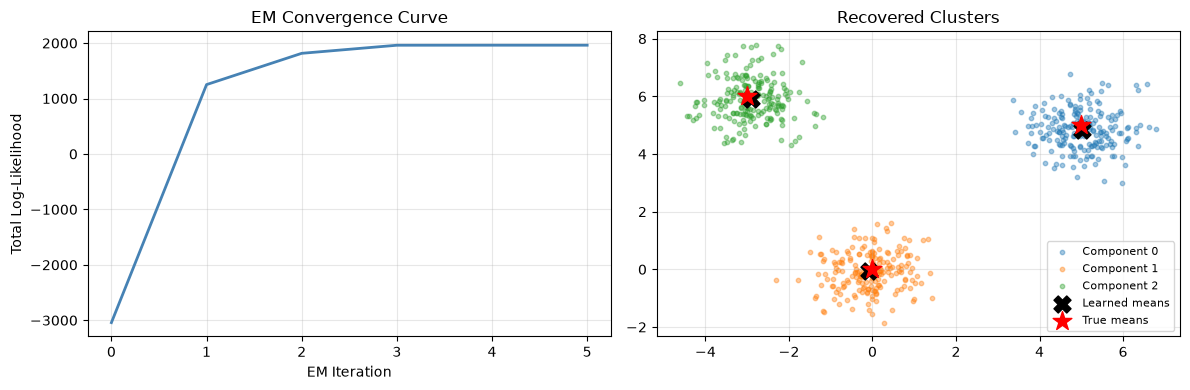

In [74]:
# ── GMM Tests ─────────────────────────────────────────────────────────────
# Synthetic 2-D data from a known 3-component GMM
rng = np.random.default_rng(7)
true_means = np.array([[0, 0], [5, 5], [-3, 6]], dtype=float)
X_syn = np.vstack(
    [
        rng.multivariate_normal(true_means[0], np.eye(2) * 0.5, 200),
        rng.multivariate_normal(true_means[1], np.eye(2) * 0.5, 200),
        rng.multivariate_normal(true_means[2], np.eye(2) * 0.5, 200),
    ]
)

gmm_test = GMM(n_components=3, max_iter=50, random_state=42)
gmm_test.fit(X_syn)

# 1. Log-likelihood should increase (or stay equal) each iteration
ll = gmm_test.log_likelihoods_
assert len(ll) > 1, "❌ No log-likelihood history recorded"
diffs = np.diff(ll)
assert np.all(diffs >= -1e-3), f"❌ Log-likelihood decreased: {diffs.min():.4f}"
print(f"Log-likelihood range: {ll[0]:.1f} → {ll[-1]:.1f} ({len(ll)} iterations)")

# 2. Recovered means should be close to the true means (within ±0.5)
learned = np.sort(gmm_test.means_, axis=0)
truth = np.sort(true_means, axis=0)
assert (
    np.abs(learned - truth).max() < 0.5
), "❌ Learned means differ too much from truth"
print(f"Max mean error: {np.abs(learned - truth).max():.3f}")

# 3. score_samples shape
scores = gmm_test.score_samples(X_syn)
assert scores.shape == (len(X_syn),), "❌ score_samples shape wrong"
print("✅ All GMM tests passed!")

# Plot log-likelihood curve and recovered clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ll, color="steelblue", lw=2)
ax1.set_xlabel("EM Iteration")
ax1.set_ylabel("Total Log-Likelihood")
ax1.set_title("EM Convergence Curve")
ax1.grid(alpha=0.3)

r_final, _ = gmm_test._e_step(X_syn)
labels = np.argmax(r_final, axis=1)
for k in range(3):
    pts = X_syn[labels == k]
    ax2.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4, label=f"Component {k}")
ax2.scatter(
    gmm_test.means_[:, 0],
    gmm_test.means_[:, 1],
    c="black",
    marker="X",
    s=150,
    zorder=5,
    label="Learned means",
)
ax2.scatter(
    true_means[:, 0],
    true_means[:, 1],
    c="red",
    marker="*",
    s=200,
    zorder=5,
    label="True means",
)
ax2.set_title("Recovered Clusters")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔵 Part 5 — Build the Generative Classifier

With `PCA` and `GMM` working, build the classifier that ties everything together: one GMM per digit class, combined via Bayes' rule to make a prediction.

No hints — use the mathematical definition in the background section: $\hat{y} = \arg\max_{c} \left[ \log p(\mathbf{x} \mid c) + \log p(c) \right]$, where $\log p(\mathbf{x}\mid c)$ comes from class $c$'s fitted `GMM.score_samples` and $\log p(c)$ is the log of that class's empirical frequency in the training data.

> 📚 **Why the argmax of $\log p(\mathbf{x}\mid c) + \log p(c)$?** By [Bayes' theorem](https://en.wikipedia.org/wiki/Bayes%27_theorem), $p(c \mid \mathbf{x}) = \dfrac{p(\mathbf{x}\mid c)\,p(c)}{p(\mathbf{x})}$. The denominator $p(\mathbf{x})$ doesn't depend on $c$, so it doesn't affect which class maximises the posterior — and since $\log$ is monotonic, maximising $p(\mathbf{x}\mid c)p(c)$ is the same as maximising the sum of their logs. This is exactly [MAP (maximum a posteriori) estimation](https://en.wikipedia.org/wiki/Maximum_a_posteriori_estimation).

<details>
<summary>💡 <b>Pseudocode — GMMClassifier.fit</b> (click to expand)</summary>

```text
function fit(X, y):
    pca   = PCA(n_pca).fit(X)
    X_pca = pca.transform(X)

    for each class c in classes_:
        X_c        = rows of X_pca where y == c
        gmm_c      = GMM(n_components).fit(X_c)
        store gmm_c
        store log( count(y == c) / N ) as the log-prior for class c

    return self
```

</details>

<details>
<summary>💡 <b>Pseudocode — GMMClassifier.predict</b> (click to expand)</summary>

```text
function predict(X):
    scores = log_scores(X)                       # (N, n_classes)
    return, for each row, the class with the highest score
```

</details>

<details>
<summary>💡 <b>Pseudocode — GMMClassifier.log_scores</b> (click to expand)</summary>

```text
function log_scores(X):
    X_pca = pca.transform(X)
    for each class c:
        scores[:, c] = gmm_c.score_samples(X_pca) + log_prior_c
    return scores   # (N, n_classes), log-space — NOT normalised probabilities
```

</details>

In [75]:
class GMMClassifier:
    """
    Generative digit classifier:
      1. Reduce dimensionality with PCA.
      2. Fit one GMM per class.
      3. Predict via MAP: argmax_c [ log p(x|c) + log p(c) ].

    Parameters
    ----------
    n_pca        : int — PCA components to keep
    n_components : int — GMM components per class
    max_iter     : int — EM iterations per GMM
    """

    def __init__(self, n_pca=50, n_components=4, max_iter=60):
        self.n_pca = n_pca
        self.n_components = n_components
        self.max_iter = max_iter
        self.pca_ = None  # fitted PCA object
        self.gmms_ = {}  # dict: class label → fitted GMM
        self.log_priors_ = {}  # dict: class label → log prior
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "GMMClassifier":
        """
        Fit PCA on X, then fit one GMM per class in reduced space.
        Also compute and store log-priors.

        Parameters
        ----------
        X : np.ndarray (N, D)   — raw pixel data
        y : np.ndarray (N,)     — integer labels

        Returns
        -------
        self
        """
        self.classes_ = np.unique(y)

        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        self.pca_ = PCA(n_components=self.n_pca)
        self.pca_.fit(X)
        X_reduced = self.pca_.transform(X)

        for c in self.classes_:
            self.gmms_[c] = GMM(n_components=self.n_components, max_iter=self.max_iter)
            X_c = X_reduced[y == c]
            self.gmms_[c].fit(X_c)
            self.log_priors_[c] = np.log(np.sum(y == c) / len(y))

        # ───────────────────────────────────────────────────────────────────
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict digit labels for each row of X.

        Parameters
        ----------
        X : np.ndarray (N, D)

        Returns
        -------
        np.ndarray (N,) of predicted integer labels
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        scores = self.log_scores(X)
        return self.classes_[np.argmax(scores, axis=1)]
     

        # ───────────────────────────────────────────────────────────────────

    def log_scores(self, X: np.ndarray) -> np.ndarray:
        """
        Return log-score matrix of shape (N, n_classes).
        scores[n, j] = log p(x_n | class j) + log p(class j)
        Column j corresponds to self.classes_[j].
        These are log-space values, not probabilities.
        """
        # ── YOUR CODE ──────────────────────────────────────────────────────

        # TODO
        X_pca = self.pca_.transform(X)
        scores = np.zeros((X.shape[0], len(self.classes_)))
        for k in range(len(self.classes_)):
            scores[:, k] = self.gmms_[self.classes_[k]].score_samples(X_pca) + self.log_priors_[self.classes_[k]]
        return scores

        # ───────────────────────────────────────────────────────────────────


print("GMMClassifier defined — implement fit / predict / log_scores, then run Part 5.")

GMMClassifier defined — implement fit / predict / log_scores, then run Part 5.


---
## 🔵 Part 6 — Train, Evaluate, and Visualise

Run the cells below once your classifier is implemented. No coding required — just observe and understand the output.

The evaluation cells use [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) and [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) from sklearn — these compute standard metrics from your predictions, they do not implement any part of the classifier itself.

In [76]:
# Train
print("Training GMMClassifier (50 PCA dims, 4 GMM components, 60 EM iterations)...")
clf = GMMClassifier(n_pca=50, n_components=4, max_iter=60)
clf.fit(X_train, y_train)
print("Done.")

# Predict
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {acc*100:.2f}%")

# ── Comparison with K-Means baselines ────────────────────────────────────────
try:
    print(f"\n  K-Means  K=1  (nearest centroid) : {acc_baseline:.1f}%")
    print(f"  K-Means  K=4                     : {acc_kmeans:.1f}%")
    print(f"  GMM      K=4                     : {acc*100:.2f}%")
except NameError:
    pass  # run Part 2 first

Training GMMClassifier (50 PCA dims, 4 GMM components, 60 EM iterations)...
Done.

🎯 Test Accuracy: 96.05%

  K-Means  K=1  (nearest centroid) : 78.8%
  K-Means  K=4                     : 87.7%
  GMM      K=4                     : 96.05%


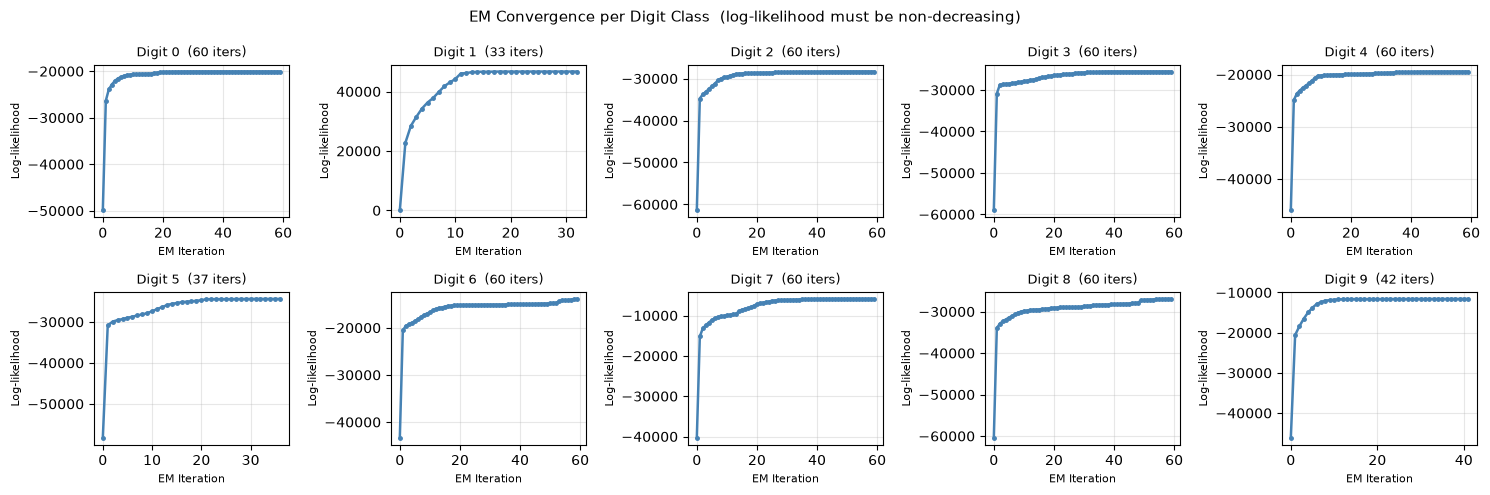

In [77]:
# ── EM convergence — log-likelihood history for all digit classes ─────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
axes = axes.flatten()

for digit, ax in enumerate(axes):
    ll = clf.gmms_[digit].log_likelihoods_
    ax.plot(ll, color="steelblue", lw=1.8, marker="o", markersize=2.5)
    ax.set_title(f"Digit {digit}  ({len(ll)} iters)", fontsize=9)
    ax.set_xlabel("EM Iteration", fontsize=8)
    ax.set_ylabel("Log-likelihood", fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    "EM Convergence per Digit Class  (log-likelihood must be non-decreasing)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [78]:
# Classification report
print(classification_report(y_test, y_pred, target_names=[str(d) for d in range(10)]))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       200
           1       1.00      0.94      0.97       200
           2       0.94      0.98      0.96       200
           3       0.93      0.93      0.93       200
           4       0.98      0.96      0.97       200
           5       0.98      0.96      0.97       200
           6       0.99      0.98      0.99       200
           7       0.97      0.94      0.95       200
           8       0.89      0.96      0.93       200
           9       0.95      0.95      0.95       200

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



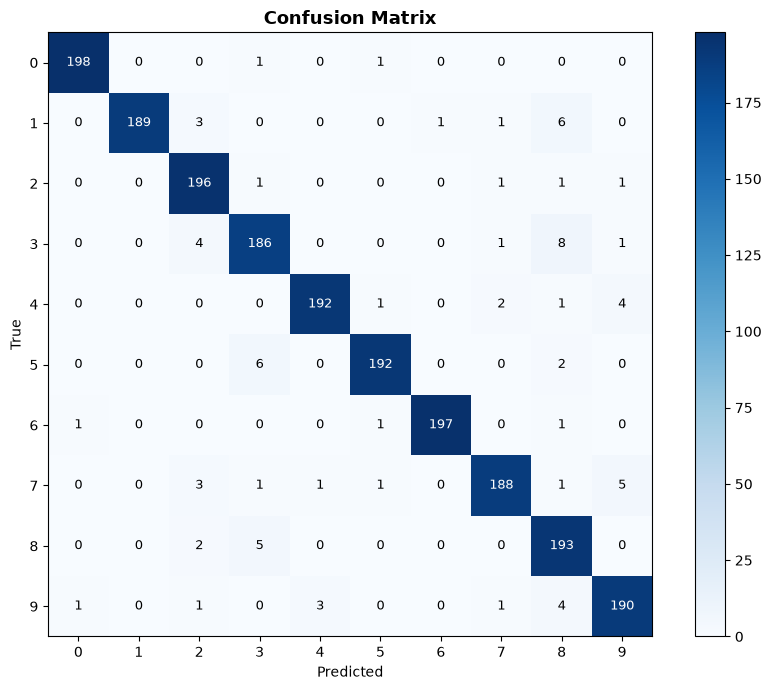


Per-class accuracy:
  Digit 0:  99.0%  ███████████████████
  Digit 1:  94.5%  ██████████████████
  Digit 2:  98.0%  ███████████████████
  Digit 3:  93.0%  ██████████████████
  Digit 4:  96.0%  ███████████████████
  Digit 5:  96.0%  ███████████████████
  Digit 6:  98.5%  ███████████████████
  Digit 7:  94.0%  ██████████████████
  Digit 8:  96.5%  ███████████████████
  Digit 9:  95.0%  ███████████████████


In [79]:
# Confusion matrix
import matplotlib.ticker as ticker

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
for i in range(10):
    for j in range(10):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=9,
        )
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
for i in range(10):
    ca = cm[i, i] / cm[i].sum() * 100
    print(f"  Digit {i}: {ca:5.1f}%  {'█' * int(ca / 5)}")

Misclassified: 79 / 2000


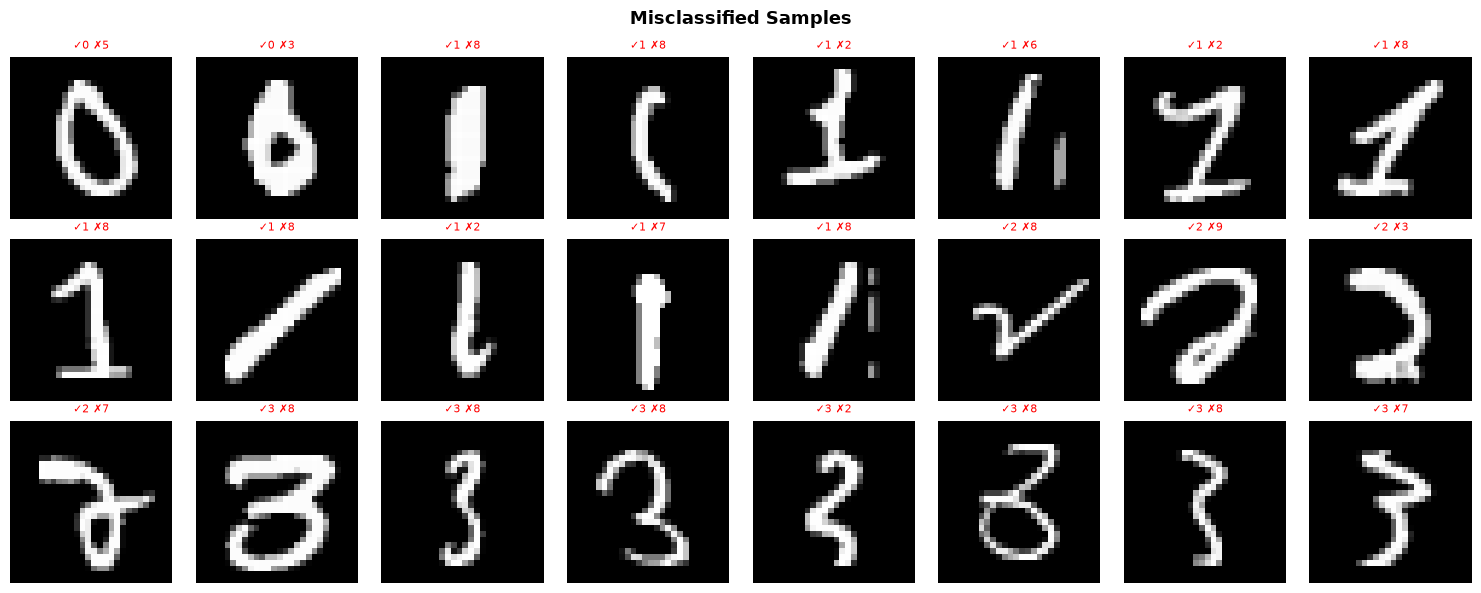

In [80]:
# Visualise misclassified samples
wrong = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(wrong)} / {len(y_test)}")

fig, axes = plt.subplots(3, 8, figsize=(15, 6))
fig.suptitle("Misclassified Samples", fontsize=13, fontweight="bold")
for ax, idx in zip(axes.flatten(), wrong[:24]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"✓{y_test[idx]} ✗{y_pred[idx]}", fontsize=8, color="red")
    ax.axis("off")
plt.tight_layout()
plt.show()

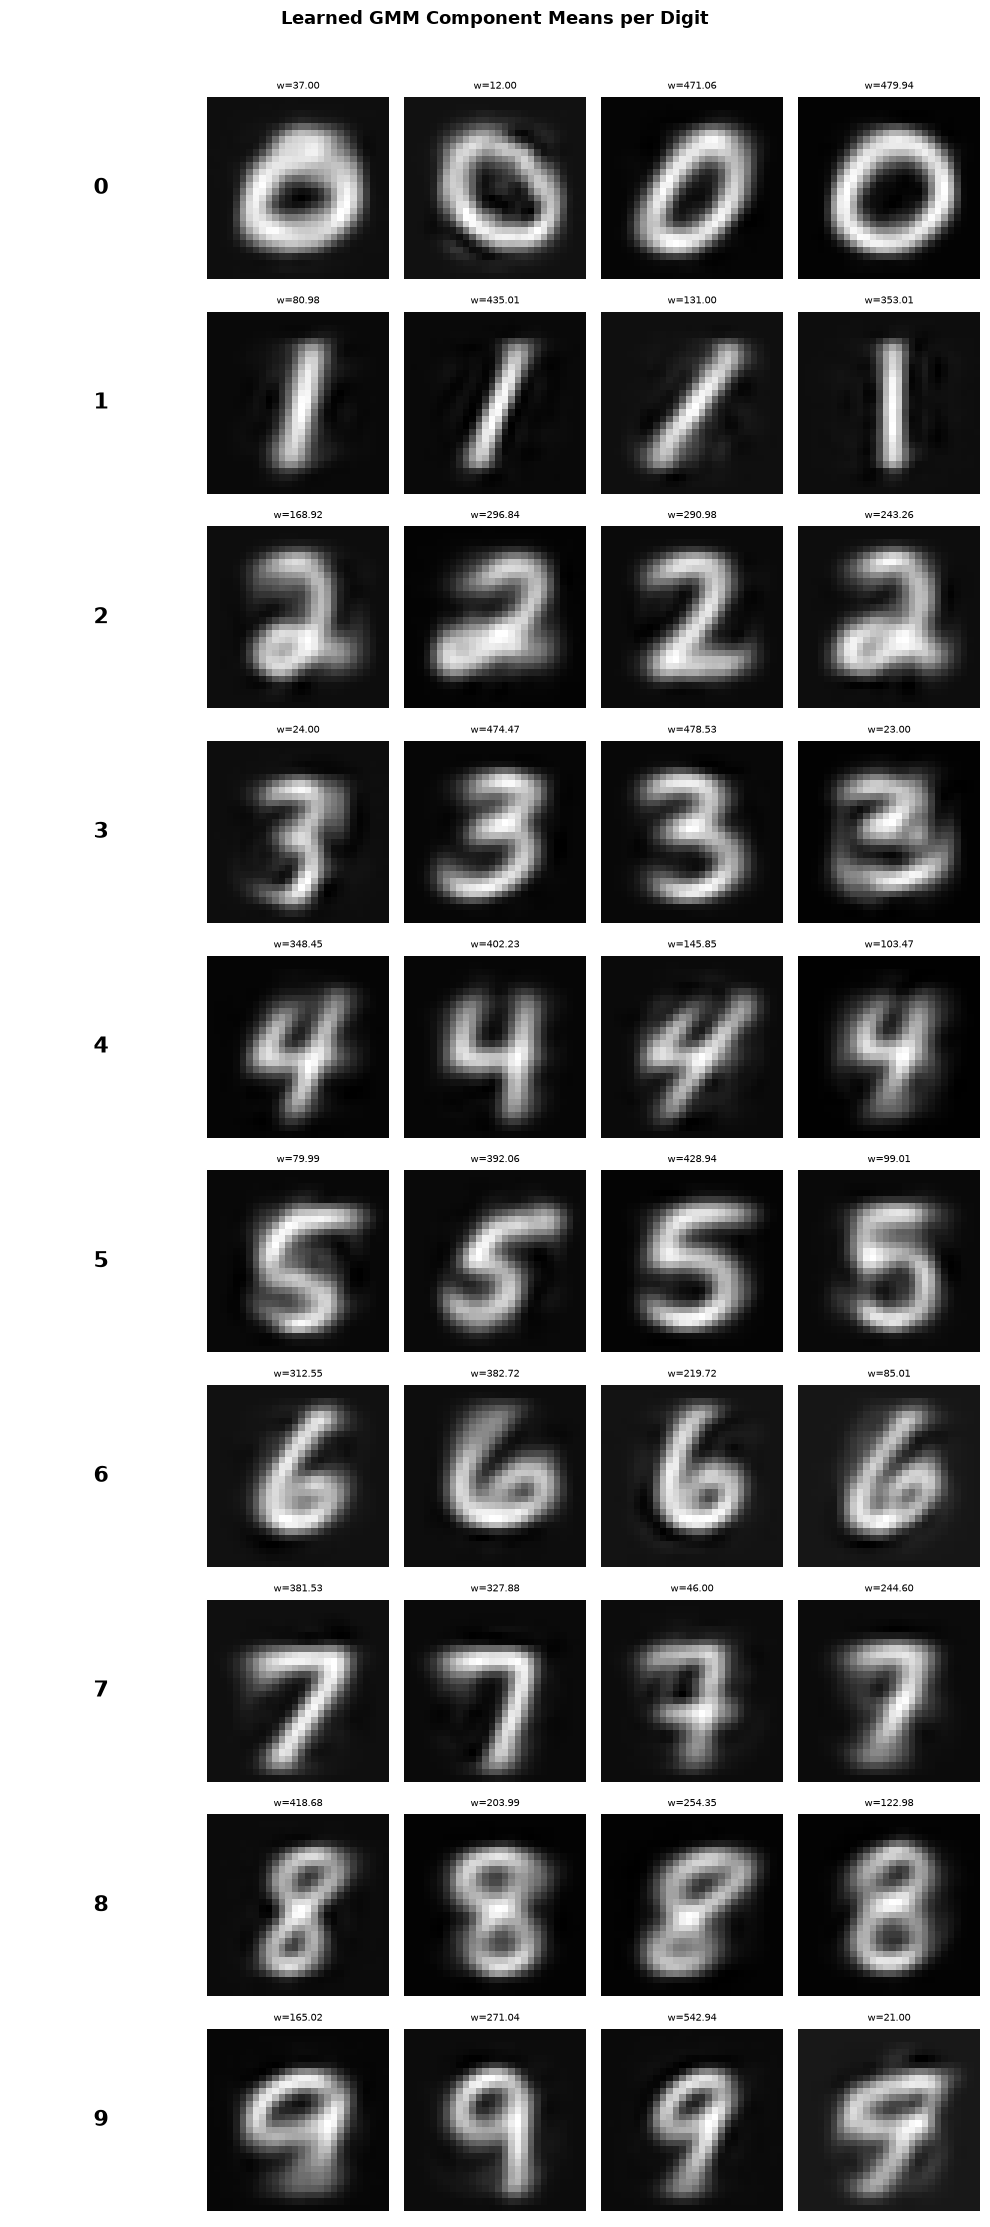

In [81]:
# Visualise GMM component means projected back to pixel space
n_comp = clf.n_components
fig, axes = plt.subplots(10, n_comp + 1, figsize=(2 * (n_comp + 1), 22))
fig.suptitle(
    "Learned GMM Component Means per Digit", fontsize=13, fontweight="bold", y=1.01
)

for digit in range(10):
    gmm = clf.gmms_[digit]
    axes[digit, 0].text(
        0.5, 0.5, str(digit), ha="center", va="center", fontsize=16, fontweight="bold"
    )
    axes[digit, 0].axis("off")
    means_pixel = clf.pca_.inverse_transform(gmm.means_)
    for k in range(n_comp):
        axes[digit, k + 1].imshow(means_pixel[k].reshape(28, 28), cmap="gray")
        axes[digit, k + 1].set_title(f"w={gmm.weights_[k]:.2f}", fontsize=7)
        axes[digit, k + 1].axis("off")

plt.tight_layout()
plt.show()

---
## 🔵 Part 7 — Hyperparameter Study

Systematically explore how `n_pca` and `n_components` (GMM) affect accuracy.

### ✏️ YOUR TASK

1. Choose **at least 3 values** for each hyperparameter below.
2. Run the grid, plot the results, and write a short analysis in the markdown cell that follows.

In [82]:
# ── Choose your hyperparameter grids ──────────────────────────────────────
# ⚠️  Runtime tip: each configuration trains 10 GMMs × max_iter EM steps.
# For quick exploration reduce max_iter or subsample the training data:
#   X_tr_exp, y_tr_exp = X_train[:3000], y_train[:3000]
n_pca_grid = [20, 50, 80]  # TODO: at least 3 values
n_gmm_grid = [2, 4, 8]  # TODO: at least 3 values
# ──────────────────────────────────────────────────────────────────────────

results = []
for n_pca in n_pca_grid:
    for n_gmm in n_gmm_grid:
        print(f"  n_pca={n_pca}, n_gmm={n_gmm} ... ", end="", flush=True)
        clf_exp = GMMClassifier(n_pca=n_pca, n_components=n_gmm, max_iter=40)
        clf_exp.fit(X_train, y_train)
        acc_exp = accuracy_score(y_test, clf_exp.predict(X_test)) * 100
        results.append({"n_pca": n_pca, "n_gmm": n_gmm, "accuracy": acc_exp})
        print(f"{acc_exp:.2f}%")

print("\n✅ Grid search complete!")

  n_pca=20, n_gmm=2 ... 95.45%
  n_pca=20, n_gmm=4 ... 95.75%
  n_pca=20, n_gmm=8 ... 95.50%
  n_pca=50, n_gmm=2 ... 96.25%
  n_pca=50, n_gmm=4 ... 96.00%
  n_pca=50, n_gmm=8 ... 95.30%
  n_pca=80, n_gmm=2 ... 94.95%
  n_pca=80, n_gmm=4 ... 94.70%
  n_pca=80, n_gmm=8 ... 94.65%

✅ Grid search complete!


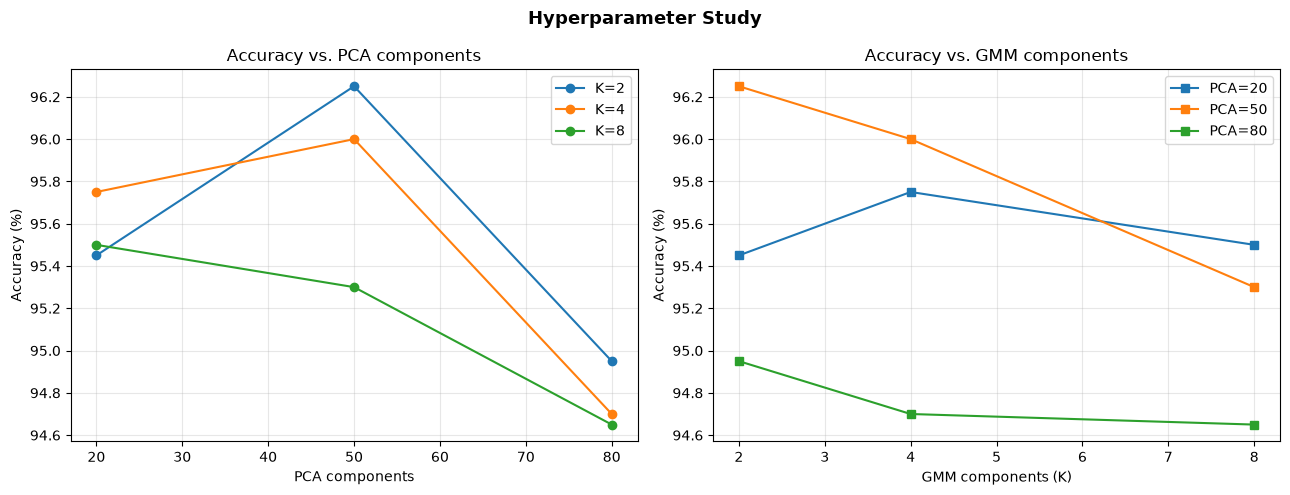


🏆 Best: n_pca=50, K=2 → 96.25%


In [83]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Hyperparameter Study", fontsize=13, fontweight="bold")

for n_gmm in n_gmm_grid:
    sub = [(r["n_pca"], r["accuracy"]) for r in results if r["n_gmm"] == n_gmm]
    xs, ys = zip(*sorted(sub))
    axes[0].plot(xs, ys, marker="o", label=f"K={n_gmm}")
axes[0].set_xlabel("PCA components")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy vs. PCA components")
axes[0].legend()
axes[0].grid(alpha=0.3)

for n_pca in n_pca_grid:
    sub = [(r["n_gmm"], r["accuracy"]) for r in results if r["n_pca"] == n_pca]
    xs, ys = zip(*sorted(sub))
    axes[1].plot(xs, ys, marker="s", label=f"PCA={n_pca}")
axes[1].set_xlabel("GMM components (K)")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy vs. GMM components")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best = max(results, key=lambda r: r["accuracy"])
print(f"\n🏆 Best: n_pca={best['n_pca']}, K={best['n_gmm']} → {best['accuracy']:.2f}%")

### ✏️ Analysis

Write 3–5 sentences below interpreting the plots:
- What happens to accuracy as you increase PCA components?
- What happens as you increase GMM components?
- Is there a point of diminishing returns? Did you observe any decrease in accuracy?

> Increasing the number of PCA components, accuracy increased from 95.5% at 20 components to a peak of 96.25% at 50 components. But the fell to 94.7% at 80 components. The first 50 components capture a discriminative shape information, while extra dimensions add noise, forces GMM to estimate a much larger covariance matrix.

> Increasing the GMM components per class didn't help in my grid, At the best PCA setting (50 dims), K=2 gave 96.25%, K=4 gave 96.00%, and K=8 dropped to 95.30%. With only 1,000 training images per digit, adding more Gaussians splits the data too thinly: each component is estimated from fewer points, its covariance becomes less reliable, and the model starts to overfit rather than capture genuinely new writing styles.

> Yes, there is a clear point of diminshing returns and even a measurable decrease in accuracy in both direction. The best configuration was n_pca = 50, K = 2 give 96.25%, which balances expressive power against having enough data to estimate each covariance matrix reliably.

---
## 📝 Part 8 — Reflection Questions

Answer **all four questions** in the cells below.

### Q1 — PCA & the Curse of Dimensionality

MNIST images have 784 dimensions. Explain **two specific problems** that would arise if you tried to fit a GMM directly in 784-D space without PCA. Be precise — refer to the covariance matrix and the EM algorithm.

> Each component needs a 784×784 covariance matrix, which has about 784·785/2 ≈ 307,000 free parameters. With only ~1,000 training images per digit, there are far fewer data points than parameters, so the estimated covariance matrix is rank-deficient (singular). The Gaussian log-pdf requires `Σ⁻¹` and `log|Σ|`; for a singular matrix the determinant is ~0 and the inverse is undefined, so the whole likelihood computation blows up (NaNs / infinities) or is wildly unstable. On top of that, many MNIST pixels (the corners/borders) are always 0, giving those dimensions exactly zero variance — an immediate singularity.

> Every E-step evaluates the multivariate Gaussian in 784-D, and every M-step re-estimates and inverts a 784×784 matrix per component per iteration — an `O(D³)` cost that is enormous compared to working in 50-D. Beyond the raw cost, in such high dimensions distances between points become nearly uniform (the curse of dimensionality), so responsibilities are poorly separated and EM converges slowly to poor local optima. PCA fixes both problems at once: reducing to ~50 dimensions gives well-conditioned, invertible covariance matrices that can actually be estimated from the available data.

### Q2 — The Log-Sum-Exp Trick

In the E-step you were advised to use the log-sum-exp trick. Show with a **concrete numerical example** (choose any numbers you like) why computing `exp(log_probs)` directly before summing can cause numerical underflow, and how the trick fixes it.

> In the E-step we need `log Σ_k π_k N(x | μ_k, Σ_k)`, but in ~50-D the individual log-terms are large negative numbers. Suppose for one point the three log-terms are:

```
ℓ = [-1000, -1002, -1005]
```
>`exp(-1000)`, `exp(-1002)`, `exp(-1005)` are all far below the smallest number `float64` can represent (~1e-308), so each one underflows to exactly 0.0. Summing gives `0.0`, and `log(0.0) = -inf`. The information is completely lost, and any downstream division to normalise the responsibilities becomes `0/0 = NaN`.

>Let `m = max(ℓ) = -1000`. Then

```
log Σ_k exp(ℓ_k) = m + log Σ_k exp(ℓ_k - m)
```
>The shifted terms `ℓ - m = [0, -2, -5]` exponentiate to `[1.0, 0.135, 0.0067]`, which are perfectly safe to sum =`1.142`. So the result is `-1000 + log(1.142) = -999.87`, a correct, finite answer. The largest term (which dominates the sum anyway) is always exactly `exp(0)=1`, so it never underflows, and the trick recovers the true log-sum without any overflow or underflow.

### Q3 — Confusion Matrix

Look at your confusion matrix from Part 5. Name the **two digit pairs most frequently confused** by your classifier. Hypothesise why, and suggest one modification to the pipeline that might reduce that confusion.

> The two digit pairs my classifier confuses most often are 3 - 8 and 4 - 9. In my confusion matrix, 3↔8 was by far the largest off-diagonal pair (13 misclassifications combined - 8 threes predicted as eights and 5 eights predicted as threes), followed by 4-9 (7 combined). A few others were close behind (7-9, 3-5, 1-8, each around 6).

>These digits share most of their pixel-level structure. An 8 is essentially a 3 with the left side of its loops closed, so a rounded or overlapping 3 looks almost identical to an 8. A 4 and a 9 differ mainly in whether the top loop is closed. After projecting to 50 PCA dimensions - which capture broad shape rather than fine local strokes - those small distinguishing details (one open vs. closed curve) are largely smoothed away, so the per-class Gaussians for these digits overlap heavily and the MAP rule picks the wrong one on the ambiguous, sloppily-written examples. The low precision on digit 8 (0.89) in the classification report confirms that several other digits are being pulled into the "8" class.

>Keep more PCA components (or use features that preserve local stroke detail) so the distinguishing curves/loops survive dimensionality reduction - or increase the number of GMM components per class so each digit's distinct writing styles are modelled separately instead of being merged into one overlapping blob.

### Q4 — GMM vs. Discriminative Models

A Convolutional Neural Network typically achieves >99% accuracy on MNIST, compared to ~85–90% for this GMM approach. Explain **two fundamental reasons** (not just "CNNs have more parameters") why the generative GMM approach is at a disadvantage here.

> The GMM is *generative*: each class's GMM is trained only on that class's own data to model how its images are distributed, with no knowledge of the other classes. It spends its capacity describing *what a digit looks like* rather than *what separates one digit from another*. A CNN is *discriminative*: it directly optimises `p(c|x)`, so every parameter is tuned to place decision boundaries between classes. For classification, modelling the boundary directly is far more efficient than accurately modelling each full class density and hoping the boundaries fall out correctly.

> The GMM (even after PCA) treats an image as an unstructured 784- (or 50-) dimensional vector, so a digit shifted, rotated, or scaled by a few pixels looks like a completely different point. A CNN uses convolutions and pooling to build **translation-invariant, hierarchical features** (edges - strokes - shapes), so it recognises the same digit regardless of small spatial variations. The GMM has no built-in notion that neighbouring pixels are related or that a shifted digit is the same digit, which caps how well it can generalise on image data.

---
## ⭐ Bonus Challenges

Complete **at least one** for full marks on the bonus section.

### Bonus A — Generate New Digits

Add a `sample(n)` method to your `GMM` class that:
1. Samples a component $k$ from the multinomial distribution over $\pi_k$
2. Samples a point from $\mathcal{N}(\mu_k, \Sigma_k)$

Then, for each digit 0–9, generate 5 synthetic samples, project them back to pixel space via `pca_.inverse_transform`, and display them. Do they look like plausible digits?

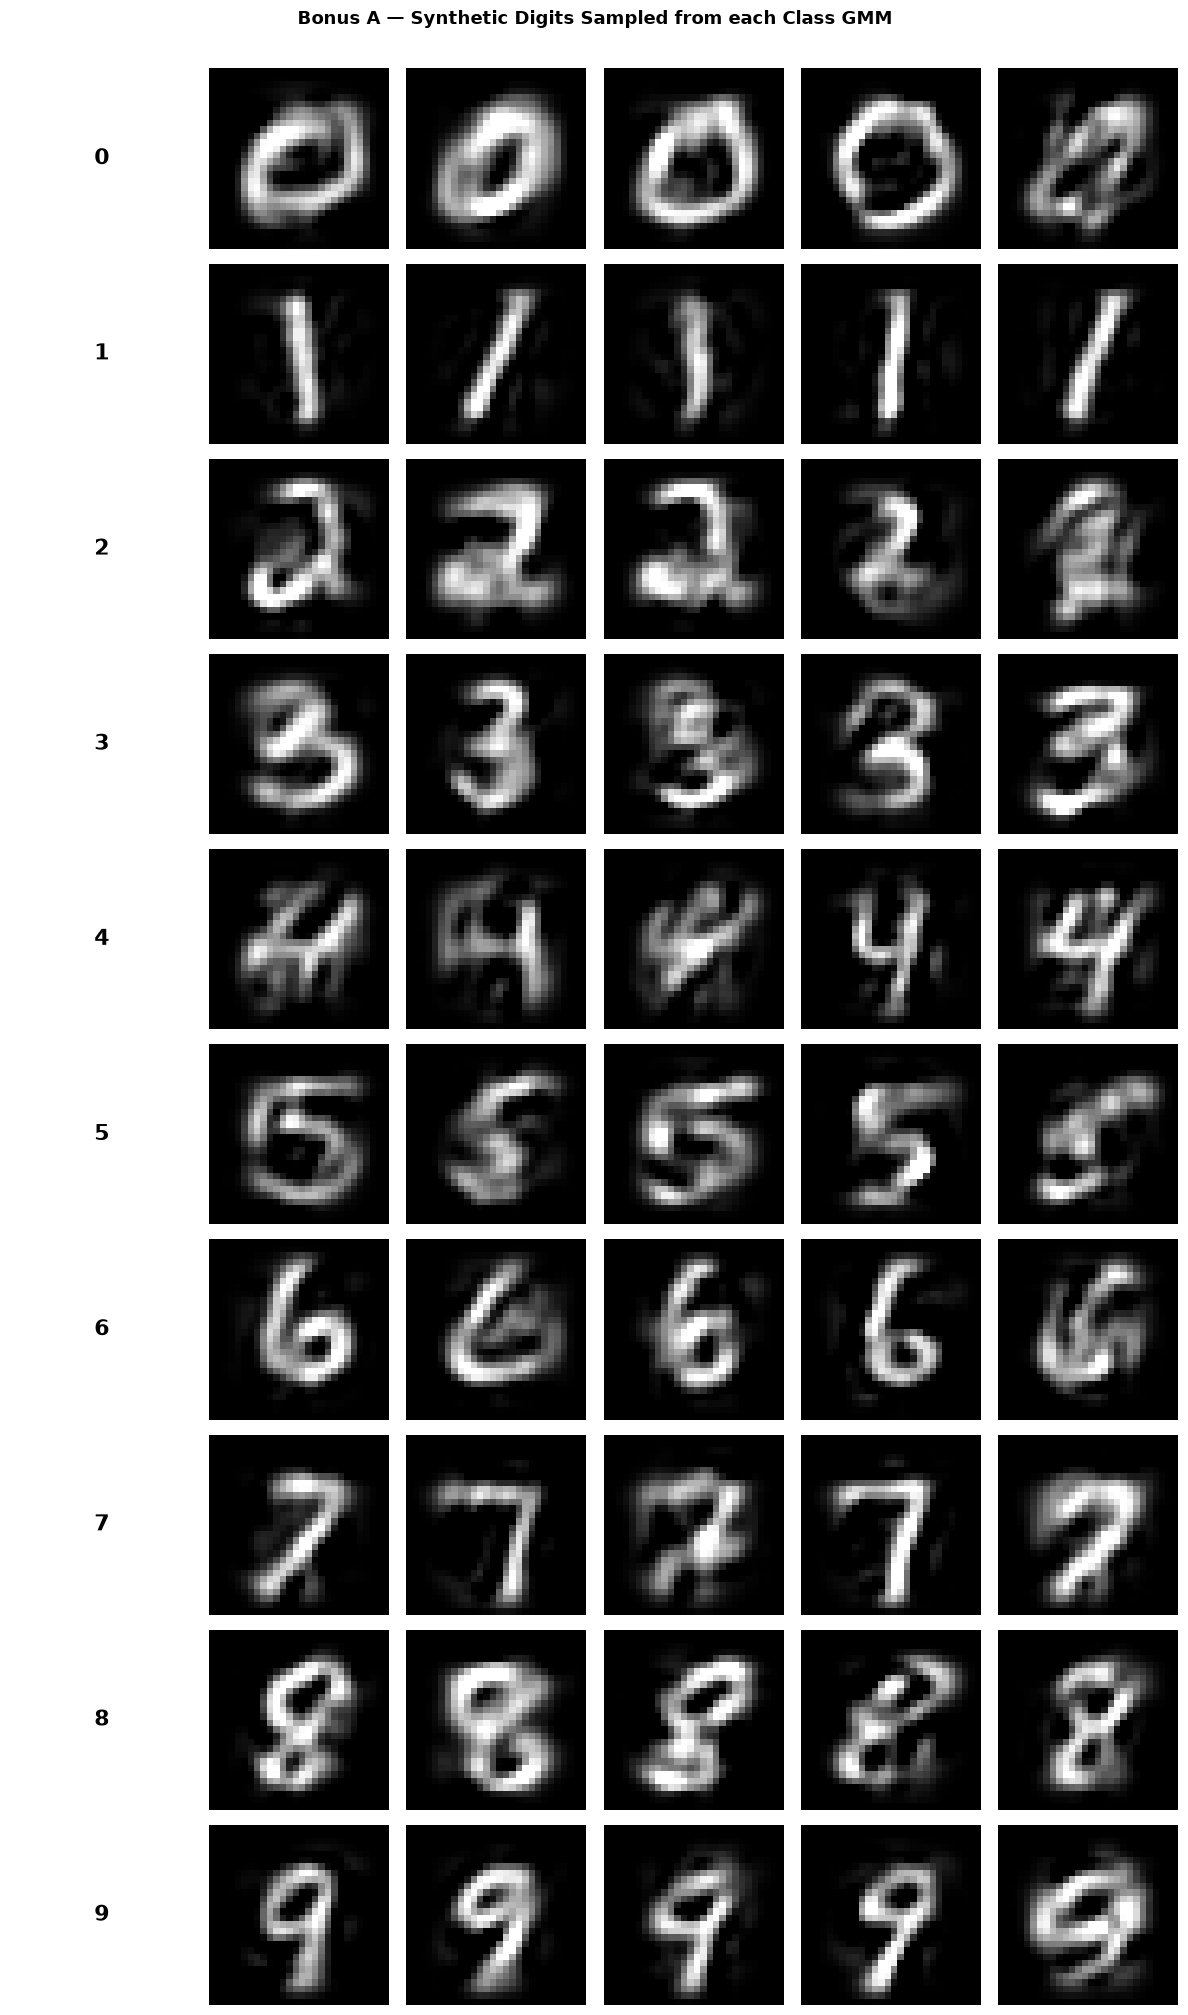

In [84]:
# ── Bonus A — Generate New Digits ──────────────────────────────────────────
# For each digit 0-9, sample 5 points from that class's fitted GMM (in PCA
# space), project them back to 784-D pixel space, and display them.

n_per_digit = 5
fig, axes = plt.subplots(
    10, n_per_digit + 1, figsize=(2 * (n_per_digit + 1), 20)
)
fig.suptitle(
    "Bonus A — Synthetic Digits Sampled from each Class GMM",
    fontsize=13, fontweight="bold", y=1.005,
)

for digit in range(10):
    # first column: the digit label
    axes[digit, 0].text(
        0.5, 0.5, str(digit), ha="center", va="center",
        fontsize=16, fontweight="bold",
    )
    axes[digit, 0].axis("off")

    # sample in reduced space, then invert PCA back to pixels
    samples_pca = clf.gmms_[digit].sample(n_per_digit)
    samples_pixel = clf.pca_.inverse_transform(samples_pca)

    for j in range(n_per_digit):
        img = np.clip(samples_pixel[j], 0, 1).reshape(28, 28)
        axes[digit, j + 1].imshow(img, cmap="gray")
        axes[digit, j + 1].axis("off")

plt.tight_layout()
plt.show()



### Bonus B — BIC Model Selection

The **Bayesian Information Criterion** for a GMM is:

$$\text{BIC} = -2 \log \hat{L} + p \log N$$

where $\hat{L}$ is the fitted log-likelihood, $p$ is the number of free parameters, and $N$ is the number of data points. **Lower BIC is better.**

For **one digit class** of your choice:
1. Implement a `bic(X)` method on your `GMM` class.
2. Fit GMMs with $K \in \{1, 2, 4, 6, 8, 10\}$ components.
3. Plot BIC vs. $K$ and identify the optimal number of components.

In [85]:
# ── Bonus B ───────────────────────────────────────────────────────────────

# Your code here

### Bonus C — Diagonal Covariance GMM

Full covariance matrices are expensive: each $\Sigma_k$ has $O(d^2)$ parameters. Implement a `DiagonalGMM` variant that constrains each $\Sigma_k$ to be **diagonal** (only $O(d)$ parameters per component).

Compare its accuracy and training time against your full-covariance GMM. Why might the diagonal version still perform well after PCA?

In [86]:
# ── Bonus C ───────────────────────────────────────────────────────────────

# Your code here

---
## ✅ Submission Checklist

Before submitting, confirm every box below:

- [ ] `PCA.fit`, `transform`, `inverse_transform` implemented and tests pass (Part 1)
- [ ] `assign_clusters`, `update_centroids`, `kmeans` implemented (Part 2)
- [ ] `train_kmeans_classifier`, `predict_kmeans` implemented (Part 2)
- [ ] `multivariate_gaussian_log_pdf` implemented and matches scipy reference (Part 3)
- [ ] `GMM._init_params`, `_e_step`, `_m_step`, `fit`, `score_samples` implemented and tests pass (Part 4)
- [ ] `GMMClassifier.fit`, `predict`, `log_scores` implemented (Part 5)
- [ ] All Part 6 evaluation cells run with output visible
- [ ] Hyperparameter grids contain ≥ 3 values each and Part 7 analysis is written (Part 7)
- [ ] All four reflection questions answered (Part 8)
- [ ] At least one Bonus challenge attempted
- [ ] **No sklearn model classes used anywhere** (only `fetch_openml`, `accuracy_score`, `confusion_matrix`, `classification_report`)
- [ ] All cells run top-to-bottom without errors

---
*Good luck — and remember: the maths is the code. 🎯*